In [156]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
mask1_path = r"./mask-imgs/final_warp1_mask.jpg"
mask2_path = r"./mask-imgs/final_warp2_mask.jpg"


def plt_show(cv_im):
    img_rgb = cv2.cvtColor(cv_im, cv2.COLOR_BGR2RGB)
    # 使用 matplotlib 显示图像
    plt.imshow(img_rgb)
    plt.show()


mask1_im = cv2.imread(mask1_path)
mask2_im = cv2.imread(mask2_path)

In [157]:
len(mask1_im.shape), mask1_im.ndim

(3, 3)

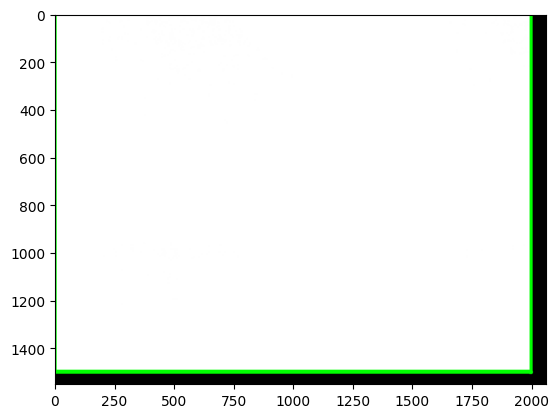

In [158]:

contours, _ = cv2.findContours(mask1_im[:,:,0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_out = cv2.drawContours(mask1_im,contours,-1,(0,255,0),thickness=12)
plt_show(img_out)


C:\Users\87486\AppData\Local\Temp\ipykernel_208708\3012317091.py:34: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


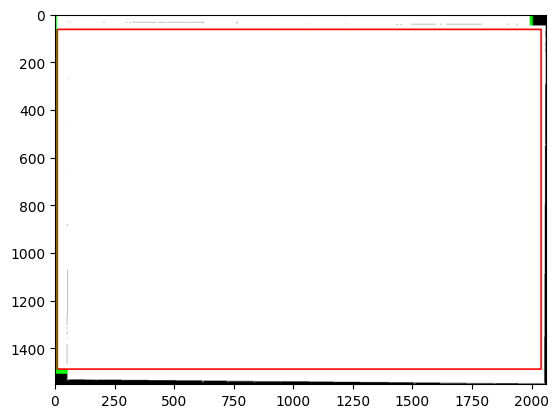

In [159]:
class COPPER:
    
    @staticmethod
    def get_contours(): # 暂时用不上
        contours, _ = cv2.findContours(mask2_im[:,:,0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        img_out = cv2.drawContours(mask2_im,contours,-1,(0,255,0),thickness=12)
        plt_show(img_out)
    
    @staticmethod
    def order_points_clockwise(pts):
        rect = np.zeros((4, 2), dtype=np.uint16)
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]
        rect[2] = pts[np.argmax(s)]
        tmp = np.delete(pts, (np.argmin(s), np.argmax(s)), axis=0)
        diff = np.diff(np.array(tmp), axis=1)
        rect[1] = tmp[np.argmin(diff)]
        rect[3] = tmp[np.argmax(diff)]
        return rect
    
    @staticmethod
    def get_max_contours_coord(gray_im):
        if len(gray_im.shape)==3:
            contours, _ = cv2.findContours(gray_im[:,:,0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 
        else:
            contours, _ = cv2.findContours(gray_im, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 
        contours, _ = cv2.findContours(gray_im[:,:,0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # 求出最大轮廓
        max_contour = max(contours, key=cv2.contourArea)
        # 计算最小内接矩形
        rect = cv2.minAreaRect(max_contour)
        # 获取最小外接矩形的四个顶点
        box = cv2.boxPoints(rect)
        box = np.int0(box)
        # print(box)
        box = COPPER.order_points_clockwise(box)
        return box  # [左上，右上，右下，左下]
    
    @staticmethod
    def cut_im_by_iou(np_box1,np_box2):
        left = np.array([box1[[0,3]][0,:],box2[[0,3]][0,:]]).min()
        right = np.array([box1[[1,2]][0,:],box2[[1,2]][0,:]]).max()
        top = np.array([box1[[0,1]][:,1],box2[[0,1]][:,1]]).max()
        bottom = np.array([box1[[2,3]][:,1],box2[[2,3]][:,1]]).min()
        return left, right, top, bottom
    
    @staticmethod
    def do(mask1_im, mask2_im):
        box1 = COPPER.get_max_contours_coord(mask1_im)
        box2 = COPPER.get_max_contours_coord(mask2_im)
        merge_mask = np.where(mask1_im+mask2_im==0, 0,255).astype(np.uint8)
        res = COPPER.cut_im_by_iou(box1, box2)
        cv2.rectangle(merge_mask, (res[0],res[2]), (res[1],res[3]), color=(255,0,0),thickness=6)
        return merge_mask
re_im = COPPER.do(mask1_im,mask2_im)
plt.imshow(re_im)